In [34]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

In [35]:
# Load the iris dataset
df = pd.read_csv('/content/iphone_purchase_records (1).csv')
df

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [36]:
X = df[['Age', 'Salary']]
X = pd.get_dummies(df, columns=['Gender'], drop_first=True)[['Age', 'Salary', 'Gender_Male']]
y = df['Purchase Iphone']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 280
Testing set size: 120


In [37]:
# Initialize and train the Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=16)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.89      0.88      0.88        73
    Purchase       0.81      0.83      0.82        47

    accuracy                           0.86       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.86      0.86      0.86       120



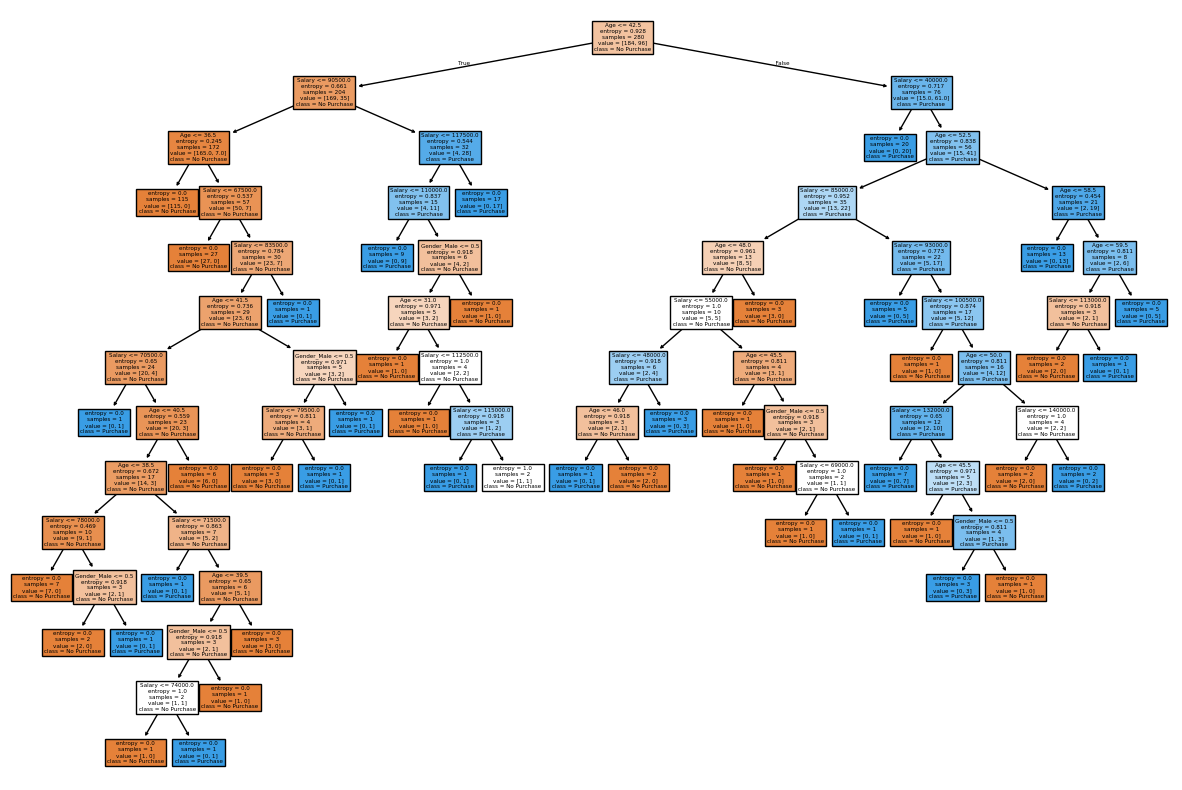

In [38]:
# Visualize the decision tree
plt.figure(figsize=(15,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['No Purchase', 'Purchase'], filled=True)
plt.show()

In [39]:
# Get the depth of the decision tree
depth = clf.get_depth()
print(f"The maximum depth of the trained decision tree is: {depth}")

The maximum depth of the trained decision tree is: 13
